/tmp/ipykernel_3651/3022254649.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


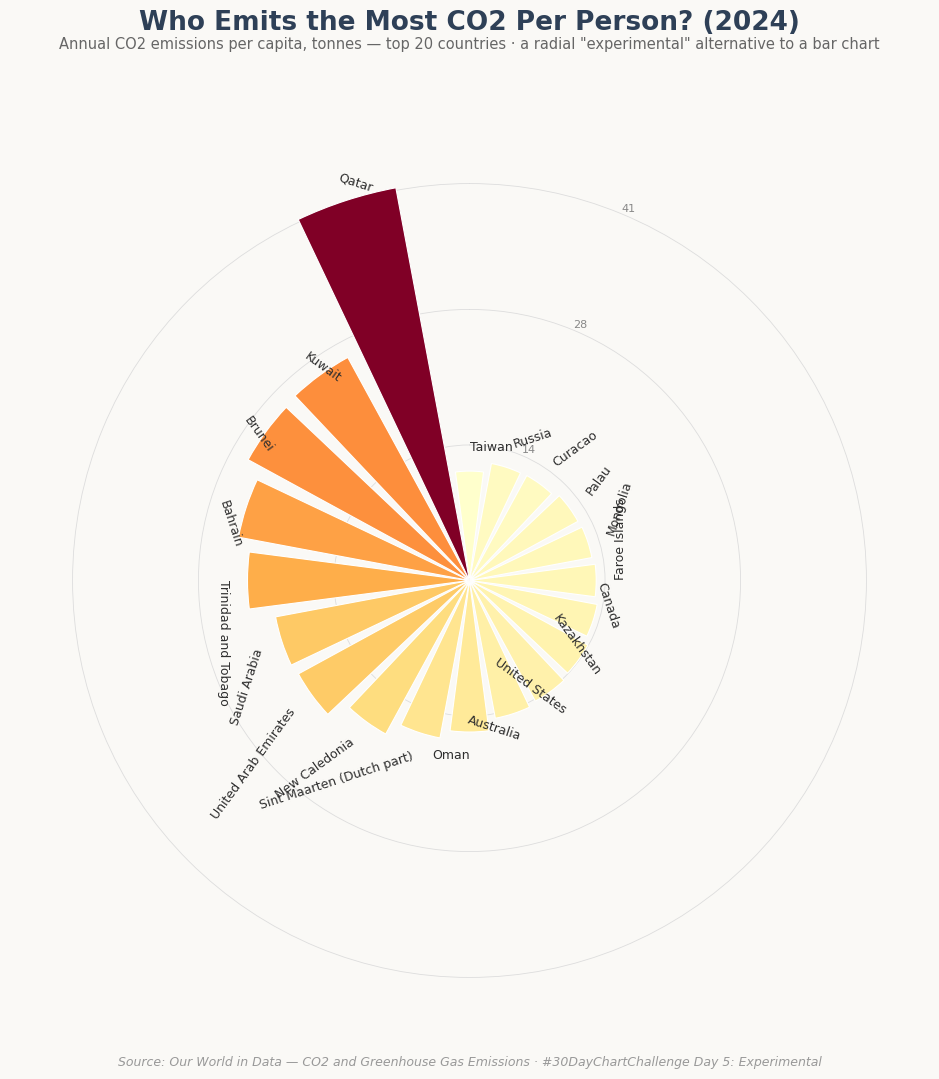

In [2]:
"""
#30DayChartChallenge — Day 5: Experimental
"Who emits the most CO2 per person?" — a polar (radial) bar chart.

Data source (loaded live, no hardcoded values):
Our World in Data — CO2 emissions per capita
https://ourworldindata.org/co2-and-greenhouse-gas-emissions

"Experimental" is an open invitation to try an unconventional chart
form. Instead of a standard horizontal/vertical bar chart, this plots
each country as a bar radiating outward from the center on a circular
(polar) axis — sometimes called a "wind rose" or "radial bar chart".
It's a genuinely different way to compare magnitudes across categories,
though it trades off precise value-reading for visual impact.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ---------------------------------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------------------------------
TOP_N = 20  # how many countries to show around the circle

DATA_URL = "https://ourworldindata.org/grapher/co-emissions-per-capita.csv?v=1&csvType=full&useColumnShortNames=false"

# ---------------------------------------------------------------------------
# 2. LOAD DATA DIRECTLY FROM SOURCE
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_URL, storage_options={"User-Agent": "Mozilla/5.0"})
value_col = [c for c in df.columns if c not in ("Entity", "Code", "Year")][0]
df = df.rename(columns={value_col: "co2_per_capita"})

# Keep only real countries (ISO-3 codes) — excludes aggregates like "World", "Asia"
countries = df[df["Code"].notna() & (df["Code"].str.len() == 3)].copy()

# Use the most recent year with broad country coverage
latest_year = int(countries["Year"].max())
latest = countries[countries["Year"] == latest_year].dropna(subset=["co2_per_capita"])

top = latest.sort_values("co2_per_capita", ascending=False).head(TOP_N).reset_index(drop=True)
# Reverse so the largest bar sits at the top (12 o'clock) going clockwise
top = top.iloc[::-1].reset_index(drop=True)

# ---------------------------------------------------------------------------
# 3. PLOT — polar (radial) bar chart
# ---------------------------------------------------------------------------
n = len(top)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
values = top["co2_per_capita"].values
labels = top["Entity"].values

fig = plt.figure(figsize=(11, 11), facecolor="#FAF9F6")
ax = fig.add_subplot(111, projection="polar")
ax.set_facecolor("#FAF9F6")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)  # clockwise

cmap = cm.get_cmap("YlOrRd")
norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
colors = [cmap(norm(v)) for v in values]

bar_width = (2 * np.pi / n) * 0.82
bars = ax.bar(angles, values, width=bar_width, color=colors, edgecolor="white", linewidth=0.8, zorder=3)

# Radial gridlines / labels
ax.set_ylim(0, values.max() * 1.15)
ax.set_yticks(np.linspace(0, values.max(), 4).round(0))
ax.tick_params(axis="y", labelsize=8, colors="#888888")
ax.set_xticks([])
ax.spines["polar"].set_visible(False)
ax.grid(color="#dddddd", linewidth=0.6)

# Country labels around the outside, rotated to match their angle
for angle, value, label in zip(angles, values, labels):
    rotation = np.degrees(angle)
    # Flip text on the left half of the circle so it reads left-to-right
    if 90 < rotation < 270:
        rotation += 180
        ha = "right"
    else:
        ha = "left"
    ax.text(
        angle, value + values.max() * 0.06, label,
        rotation=rotation, rotation_mode="anchor",
        ha=ha, va="center", fontsize=9, color="#2E2E2E",
    )

fig.suptitle(
    f"Who Emits the Most CO2 Per Person? ({latest_year})",
    fontsize=19, fontweight="bold", color="#2E4057", y=0.98,
)
fig.text(
    0.5, 0.945,
    "Annual CO2 emissions per capita, tonnes — top 20 countries · a radial \"experimental\" alternative to a bar chart",
    fontsize=10.5, color="#666666", ha="center",
)
fig.text(
    0.5, 0.02,
    "Source: Our World in Data — CO2 and Greenhouse Gas Emissions · #30DayChartChallenge Day 5: Experimental",
    fontsize=9, color="#999999", ha="center", style="italic",
)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig("day5_experimental.png", dpi=200, facecolor="#FAF9F6", bbox_inches="tight")
plt.show()